# Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.manifold import TSNE

import shap

# Main

In [4]:
df = pd.read_csv('diabetes_data_upload.csv')
df

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,Female,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,No,Positive
516,48,Female,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No,Positive
517,58,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,Yes,Positive
518,32,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No,Negative


In [5]:
df.columns

Index(['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss',
       'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring',
       'Itching', 'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'class'],
      dtype='object')

In [6]:
Counter(df['class'])

Counter({'Positive': 320, 'Negative': 200})

In [7]:
columns = [
    'Polyuria', 'Polydipsia', 'sudden weight loss',
    'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring',
    'Itching', 'Irritability', 'delayed healing', 'partial paresis',
    'muscle stiffness', 'Alopecia', 'Obesity']

for col in columns:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

In [8]:
df

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,0,1,0,1,0,0,0,1,0,1,0,1,1,1,Positive
1,58,Male,0,0,0,1,0,0,1,0,0,0,1,0,1,0,Positive
2,41,Male,1,0,0,1,1,0,0,1,0,1,0,1,1,0,Positive
3,45,Male,0,0,1,1,1,1,0,1,0,1,0,0,0,0,Positive
4,60,Male,1,1,1,1,1,0,1,1,1,1,1,1,1,1,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,Female,1,1,1,0,1,0,0,1,0,1,1,0,0,0,Positive
516,48,Female,1,1,1,1,1,0,0,1,1,1,1,0,0,0,Positive
517,58,Female,1,1,1,1,1,0,1,0,0,0,1,1,0,1,Positive
518,32,Female,0,0,0,1,0,0,1,1,0,1,0,0,1,0,Negative


# Split Data (Train/Test)

In [83]:
### Split randomly
target_col = "class"
columns = [
    target_col, 
    'weakness', 'partial paresis', 'Age', 
    'visual blurring', 'Polyphagia', 'Obesity',
    'delayed healing', 'Genital thrush', 'sudden weight loss', 'muscle stiffness',
    'Gender_Female', 'Gender_Male', 'Alopecia', 'Irritability', 'Itching',
    # 'Gender'
    ]

X = df.drop(columns=columns, errors="ignore")
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test  = le.transform(y_test)

In [84]:
X_train

,Gender,Polyuria,Polydipsia
63,Female,1,0
101,Male,1,1
157,Male,1,1
436,Male,1,1
274,Male,0,0
...,...,...,...
227,Male,0,0
170,Male,1,1
145,Male,1,0
383,Male,1,0


# Model Pipeline

In [85]:
cat_cols = [
       'Gender', 
       # 'Polyuria', 'Polydipsia', 'sudden weight loss',
       # 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring',
       # 'Itching', 'Irritability', 'delayed healing', 'partial paresis',
       # 'muscle stiffness', 'Alopecia', 'Obesity'
       ]

num_cols = [c for c in X_train.columns if c not in cat_cols]

In [86]:
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
    ]
)

# model = Pipeline([
#     ("prep", preprocess),
#     ("clf", RandomForestClassifier(
#         n_estimators=300,
#         random_state=42,
#         class_weight="balanced"
#     ))
# ])

model = Pipeline([
    ("prep", preprocess),
    ("clf", XGBClassifier(
        objective="multi:softmax",
        num_class=3,
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42
    ))
])

In [87]:
model.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [88]:
y_pred = model.predict(X_test)

In [89]:
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_micro = f1_score(y_test, y_pred, average="micro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print("F1 macro   :", f1_macro)
print("F1 micro   :", f1_micro)
print("F1 weighted:", f1_weighted)

F1 macro   : 0.9170653907496014
F1 micro   : 0.9230769230769231
F1 weighted: 0.9222181327444485


In [90]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[34  6]
 [ 2 62]]


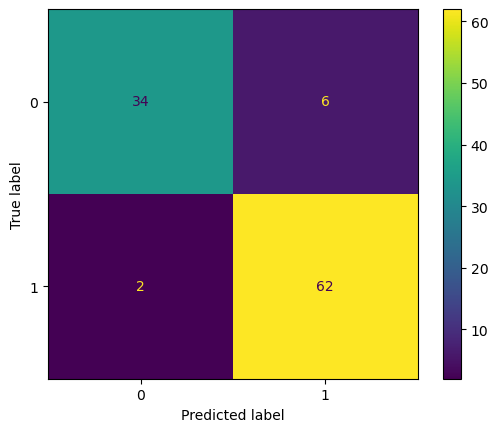

In [91]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# t-SNE

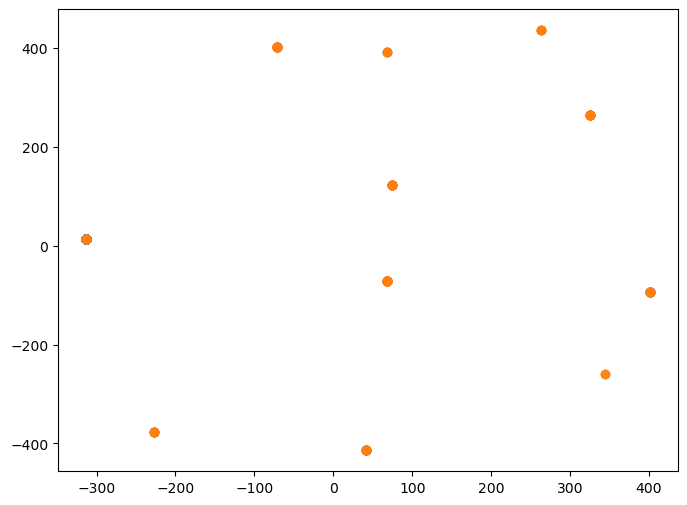

In [92]:
X_scale = preprocess.transform(X_train)
y_enc = le.fit_transform(y_train)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_scale)

tsne_df = pd.DataFrame({
    "tsne_1": X_tsne[:, 0],
    "tsne_2": X_tsne[:, 1],
    "label": y_enc
})

plt.figure(figsize=(8, 6))
for i, label in enumerate(le.classes_):
    subset = tsne_df[tsne_df["label"] == i]
    plt.scatter(
        subset["tsne_1"],
        subset["tsne_2"],
        label=label,
        alpha=0.6
    )

In [78]:
# Get the preprocessor
prep = model.named_steps["prep"]

# Numeric features stay the same
num_features = num_cols

# Categorical features after one-hot encoding
cat_features = prep.named_transformers_["cat"].get_feature_names_out(cat_cols)

# Combine numeric + OHE categorical features
feature_names = np.concatenate([num_features, cat_features])

# Get the XGBClassifier feature importances
xgb_model = model.named_steps["clf"]
importances = xgb_model.feature_importances_

# sanity check: lengths must match
assert len(feature_names) == len(importances), "Feature count mismatch!"

# 6Create feature importance DataFrame
fi = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fi.head(20)

NotFittedError: This OneHotEncoder instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.